# Marketing Campaign — Data Preprocessing & Feature Engineering

**Dataset:** `marketing_campaign.xlsx`  
**Goal:** Clean the raw data and engineer meaningful features ready for downstream modelling.

---

## Table of Contents
1. [Imports](#1)
2. [Load Data](#2)
3. [Initial Exploration](#3)
4. [Data Cleaning](#4)
   - 4.1 Missing Values
   - 4.2 Duplicate Rows
   - 4.3 Invalid Year_Birth
   - 4.4 Inconsistent Marital_Status Values
   - 4.5 Constant Columns
5. [Outlier Diagnosis — Income](#5)
6. [Feature Engineering](#7)
7. [Drop Unused Columns](#8)
8. [Final Overview](#9)

---
## 1 · Imports <a id='1'></a>

In [115]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

---
## 2 · Load Data <a id='2'></a>

In [116]:
df = pd.read_excel(r"C:\Users\Zakaria\Downloads\data-pipeline-assignment\marketing-analytics\data\marketing_campaign.xlsx")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


---
## 3 · Initial Exploration <a id='3'></a>

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [118]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [119]:
# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    print(f"\n{col} — {df[col].nunique()} unique values:")
    print(df[col].value_counts().to_string())


Education — 5 unique values:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54

Marital_Status — 8 unique values:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2

Dt_Customer — 663 unique values:
Dt_Customer
2012-08-31    12
2012-09-12    11
2013-02-14    11
2014-05-12    11
2013-08-20    10
2014-05-22    10
2014-04-05     9
2014-03-23     9
2013-01-02     9
2014-03-01     9
2012-10-29     9
2012-08-29     8
2014-05-23     8
2013-04-05     8
2012-11-09     8
2013-10-28     8
2012-08-17     8
2013-08-31     8
2013-11-07     8
2013-05-11     8
2014-05-11     8
2012-08-22     8
2013-01-12     8
2012-11-23     8
2012-11-03     8
2013-06-03     8
2013-06-04     7
2014-03-30     7
2013-11-23     7
2013-04-13     7
2014-03-17     7
2013-10-04     7
2013-01-10     7
2013-05-22     7
2014-02-07     7
2013-10-02     7
2013-10-25     7
2013-02-13  

---
## 4 · Data Cleaning <a id='4'></a>

### 4.1 · Missing Values

Only `Income` has nulls (24 rows, ≈ 1 %).  
Because it is such a small fraction and `Income` is a core feature, we **drop** those rows.

In [120]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

income_nulls = df['Income'].isnull().sum()
print(f"\nDropping {income_nulls} rows with missing Income ({income_nulls/len(df)*100:.2f}%)")
df = df.dropna(subset=['Income'])
print(f"Shape after drop: {df.shape}")

Missing values per column:
Income    24
dtype: int64

Dropping 24 rows with missing Income (1.07%)
Shape after drop: (2216, 29)


### 4.2 · Duplicate Rows

In [121]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")

Duplicate rows: 0


### 4.3 · Invalid `Year_Birth` Values

Three customers have birth years of **1893, 1899, 1900** — implying ages of 125–132.  
These are clearly data-entry errors and are removed.

In [122]:
anomalous = df[df['Year_Birth'] < 1940][['ID', 'Year_Birth']]
print(f"Anomalous Year_Birth rows ({len(anomalous)}):")
print(anomalous.to_string())

df = df[df['Year_Birth'] >= 1940]
print(f"\nShape after removing invalid birth years: {df.shape}")

Anomalous Year_Birth rows (3):
        ID  Year_Birth
192   7829        1900
239  11004        1893
339   1150        1899

Shape after removing invalid birth years: (2213, 29)


### 4.4 · Inconsistent Marital_Status Values

The column contains three non-standard categories:

| Category | Count | Action |
|----------|-------|--------|
| `Alone`  | 3     |  map to `Single` (semantically equivalent) |
| `Absurd` | 2     |  drop (nonsensical) |
| `YOLO`   | 2     |  drop (nonsensical) |

In [123]:
print("Marital_Status before cleanup:")
print(df['Marital_Status'].value_counts())

# map 'Alone' => 'Single'
df['Marital_Status'] = df['Marital_Status'].replace({'Alone': 'Single'})

# Drop 'Absurd' and 'YOLO'
dropped = df[df['Marital_Status'].isin(['Absurd', 'YOLO'])]
print(f"\n=> Dropping {len(dropped)} rows with Absurd / YOLO Marital_Status")
df = df[~df['Marital_Status'].isin(['Absurd', 'YOLO'])]

print("\nMarital_Status after cleanup:")
print(df['Marital_Status'].value_counts())
print(f"\nShape: {df.shape}")

Marital_Status before cleanup:
Marital_Status
Married     857
Together    572
Single      470
Divorced    231
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

=> Dropping 4 rows with Absurd / YOLO Marital_Status

Marital_Status after cleanup:
Marital_Status
Married     857
Together    572
Single      473
Divorced    231
Widow        76
Name: count, dtype: int64

Shape: (2209, 29)


### 4.5 · Constant Columns — Drop `Z_CostContact` and `Z_Revenue`

Both columns have **only one unique value** across the entire dataset (3 and 11 respectively).  
They carry zero information and must be removed before modelling.

In [124]:
print("Z_CostContact unique values:", df['Z_CostContact'].unique())
print("Z_Revenue     unique values:", df['Z_Revenue'].unique())

df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])
print(f"\nDropped both constant columns. Shape: {df.shape}")

Z_CostContact unique values: [3]
Z_Revenue     unique values: [11]

Dropped both constant columns. Shape: (2209, 27)


---
## 5 · Outlier Diagnosis — Income <a id='5'></a>

Income has one extreme outlier: **666,666** (clearly a test/garbage entry).  
We use IQR-based **capping** (Winsorisation) rather than deletion to retain the row.

In [125]:
# Count outliers across all continuous columns
cols_to_check = [
    'Income', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
]

print("IQR outlier counts:")
for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col:<25} {n}")

IQR outlier counts:
  Income                    8
  Recency                   0
  MntWines                  35
  MntFruits                 244
  MntMeatProducts           173
  MntFishProducts           220
  MntSweetProducts          246
  MntGoldProds              202
  NumDealsPurchases         84
  NumWebPurchases           3
  NumCatalogPurchases       23
  NumStorePurchases         0
  NumWebVisitsMonth         8


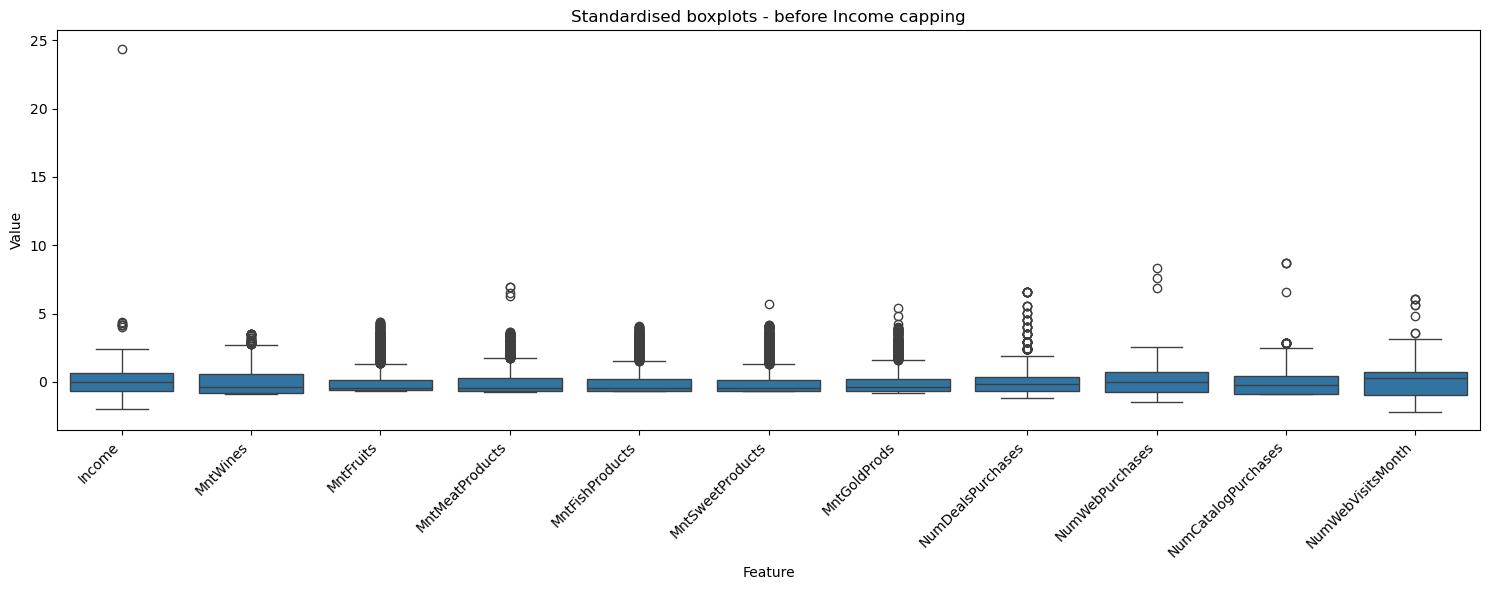

In [126]:
# Scaled boxplot => before Income capping
cols_to_plot = [
    'Income', 'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumWebVisitsMonth',
]

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[cols_to_plot]), columns=cols_to_plot)

plt.figure(figsize=(15, 6))
sns.boxplot(data=df_scaled.melt(var_name='Feature', value_name='Value'),
            x='Feature', y='Value')
plt.xticks(rotation=45, ha='right')
plt.title('Standardised boxplots - before Income capping')
plt.tight_layout()
plt.show()

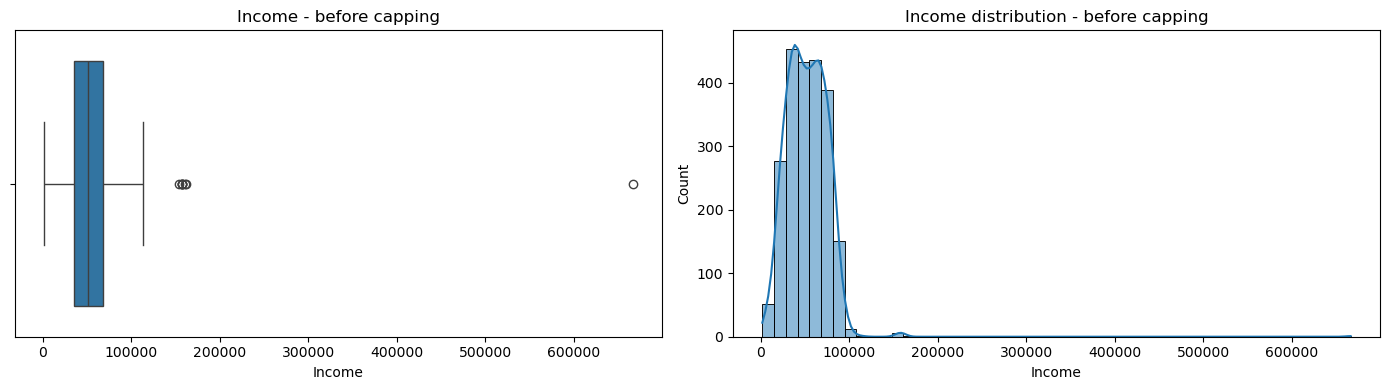

Top 5 Income values:
2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
Name: Income, dtype: float64


In [127]:
# Income distribution before capping
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=df['Income'], ax=axes[0])
axes[0].set_title('Income - before capping')
sns.histplot(df['Income'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Income distribution - before capping')
plt.tight_layout()
plt.show()

print("Top 5 Income values:")
print(df['Income'].sort_values(ascending=False).head())

In [128]:
# Cap Income with IQR
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Income'] = df['Income'].clip(lower_bound, upper_bound)
print(f"Income capped to [{lower_bound:.0f}, {upper_bound:.0f}]")

Income capped to [-14740, 118424]


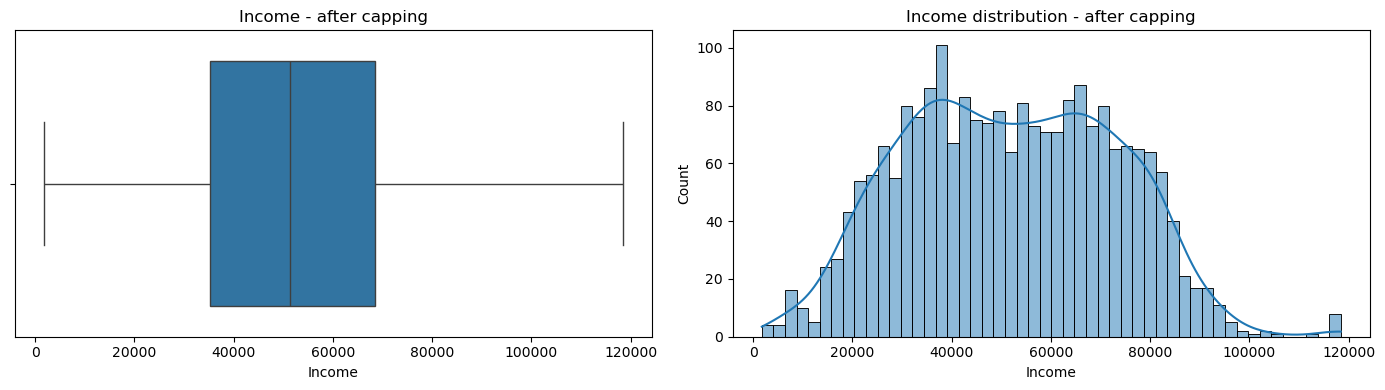

In [129]:
# Income distribution after capping
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=df['Income'], ax=axes[0])
axes[0].set_title('Income - after capping')
sns.histplot(df['Income'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Income distribution - after capping')
plt.tight_layout()
plt.show()

---
## 6 · Feature Engineering <a id='7'></a>

Seven new features that capture spending behaviour, household size, age, and engagement.

| Feature | Formula | Intuition |
|---------|---------|----------|
| `Total_Spending` | Sum of all `Mnt*` cols | Overall purchasing power |
| `Total_Purchases` | Web + Catalog + Store | Purchase frequency |
| `Average_Spend` | `Total_Spending / (Total_Purchases + 1)` | Spend per trip (+1 avoids ÷0) |
| `Family_Size` | `Kidhome + Teenhome + 1` | Household size (customer counts as 1) |
| `Age` | `current_year − Year_Birth` | Customer age (dynamic) |
| `Engagement` | `Total_Purchases / (Recency + 1)` | Activity relative to recency |
| `Spending_Ratio` | `Total_Spending / (Income + 1)` | Share of income spent |

In [130]:
# Total Spending across all product categories
df['Total_Spending'] = df[[
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]].sum(axis=1)

# Total Purchases across all channels
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

# Average spend per purchase (+1 prevents division-by-zero for customers with 0 purchases)
df['Average_Spend'] = df['Total_Spending'] / (df['Total_Purchases'] + 1)

# Household size (customer + kids + teens)
df['Family_Size'] = df['Kidhome'] + df['Teenhome'] + 1

# Age — use dynamic current year so the notebook stays correct over time
current_year = pd.Timestamp.now().year
df['Age'] = current_year - df['Year_Birth']

# Engagement: purchase rate adjusted for recency (+1 prevents division-by-zero)
df['Engagement'] = df['Total_Purchases'] / (df['Recency'] + 1)

# Spending Ratio: proportion of income spent (+1 prevents division-by-zero)
df['Spending_Ratio'] = df['Total_Spending'] / (df['Income'] + 1)

print(f"7 new features added. Shape: {df.shape}")

7 new features added. Shape: (2209, 34)


In [131]:
engineered_features = [
    'Total_Spending', 'Total_Purchases', 'Average_Spend',
    'Family_Size', 'Age', 'Engagement', 'Spending_Ratio'
]
print("Summary of engineered features:")
df[engineered_features].describe().T

Summary of engineered features:


,count,mean,std,min,25%,50%,75%,max
Total_Spending,2209.0,606.657311,602.750957,5.000000,69.000000,396.000000,1047.000000,2525.000000
Total_Purchases,2209.0,12.558624,7.208862,0.000000,6.000000,12.000000,18.000000,32.000000
Average_Spend,2209.0,34.714301,28.484727,2.000000,10.857143,27.600000,47.160000,173.230769
Family_Size,2209.0,1.948393,0.749431,1.000000,1.000000,2.000000,2.000000,4.000000
Age,2209.0,57.091897,11.696191,30.000000,49.000000,56.000000,67.000000,86.000000
Engagement,2209.0,0.696427,1.862130,0.000000,0.125000,0.250000,0.500000,27.000000
Spending_Ratio,2209.0,0.009914,0.016832,0.000051,0.002346,0.007958,0.015532,0.706699


---
## 7 · Drop Unused Columns <a id='8'></a>

Remove columns that are no longer needed for modelling:

| Column | Reason |
|--------|--------|
| `ID` | Row identifier — no predictive value |
| `Year_Birth` | Superseded by `Age` |

In [132]:
cols_to_drop = ['ID', 'Year_Birth']

df = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns. Final shape: {df.shape}")

Dropped 2 columns. Final shape: (2209, 32)


---
## 8 · Final Overview <a id='9'></a>

In [133]:
print(f"Final shape: {df.shape}")
print(f"\nOriginal rows : 2240")
print(f"Rows removed  : {2240 - df.shape[0]} (24 missing Income + 3 invalid Year_Birth + 4 junk Marital_Status)")
print(f"Final rows    : {df.shape[0]}")
print(f"\nAll columns ({df.shape[1]}):")
for col in df.columns:
    print(f"  {col}")

Final shape: (2209, 32)

Original rows : 2240
Rows removed  : 31 (24 missing Income + 3 invalid Year_Birth + 4 junk Marital_Status)
Final rows    : 2209

All columns (32):
  Education
  Marital_Status
  Income
  Kidhome
  Teenhome
  Dt_Customer
  Recency
  MntWines
  MntFruits
  MntMeatProducts
  MntFishProducts
  MntSweetProducts
  MntGoldProds
  NumDealsPurchases
  NumWebPurchases
  NumCatalogPurchases
  NumStorePurchases
  NumWebVisitsMonth
  AcceptedCmp3
  AcceptedCmp4
  AcceptedCmp5
  AcceptedCmp1
  AcceptedCmp2
  Complain
  Response
  Total_Spending
  Total_Purchases
  Average_Spend
  Family_Size
  Age
  Engagement
  Spending_Ratio


In [134]:
print("Missing values in final dataset:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "none dataset is fully clean.")

Missing values in final dataset:
none dataset is fully clean.


In [135]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Income,2209.0,51848.126754,21069.624029,1730.000000,35196.000000,51373.000000,68487.000000,118423.500000
Kidhome,2209.0,0.442734,0.537121,0.000000,0.000000,0.000000,1.000000,2.000000
Teenhome,2209.0,0.505659,0.544313,0.000000,0.000000,0.000000,1.000000,2.000000
Recency,2209.0,49.045722,28.934289,0.000000,24.000000,49.000000,74.000000,99.000000
MntWines,2209.0,305.092802,337.589199,0.000000,24.000000,174.000000,505.000000,1493.000000
MntFruits,2209.0,26.292440,39.723644,0.000000,2.000000,8.000000,33.000000,199.000000
MntMeatProducts,2209.0,166.936623,224.287848,0.000000,16.000000,68.000000,232.000000,1725.000000
MntFishProducts,2209.0,37.513807,54.569660,0.000000,3.000000,12.000000,50.000000,259.000000
MntSweetProducts,2209.0,27.053418,41.105884,0.000000,1.000000,8.000000,33.000000,262.000000
MntGoldProds,2209.0,43.768221,51.506751,0.000000,9.000000,24.000000,56.000000,321.000000


In [138]:
df.to_csv("data_cleaned.csv", index=False)
print("Saved final file as data_cleaned.csv")

Saved final file as data_cleaned.csv


In [140]:
df = pd.read_csv(r"data_cleaned.csv")
df.head()


,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp2,Complain,Response,Total_Spending,Total_Purchases,Average_Spend,Family_Size,Age,Engagement,Spending_Ratio
0,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,...,0,0,1,1617,22,70.304348,1,69,0.372881,0.027813
1,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,...,0,0,0,27,4,5.400000,3,72,0.102564,0.000583
2,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,...,0,0,0,776,20,36.952381,1,61,0.740741,0.010836
3,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,...,0,0,0,53,6,7.571429,2,42,0.222222,0.001989
4,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,...,0,0,0,422,14,28.133333,2,45,0.147368,0.007239


In [110]:
df2 = pd.read_csv(r"C:\Users\Zakaria\Downloads\data-pipeline-assignment\marketing-analytics\data_raw.csv")
df2.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [141]:
print("Missing values in final dataset:")
missing = df2.isnull().sum()
print(missing[missing > 0] if missing.any() else "none dataset is fully clean.")

Missing values in final dataset:
Income    24
dtype: int64


In [142]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [143]:
print("Missing values in final dataset:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "none dataset is fully clean.")

Missing values in final dataset:
none dataset is fully clean.


In [144]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Income,2209.0,51848.126754,21069.624029,1730.000000,35196.000000,51373.000000,68487.000000,118423.500000
Kidhome,2209.0,0.442734,0.537121,0.000000,0.000000,0.000000,1.000000,2.000000
Teenhome,2209.0,0.505659,0.544313,0.000000,0.000000,0.000000,1.000000,2.000000
Recency,2209.0,49.045722,28.934289,0.000000,24.000000,49.000000,74.000000,99.000000
MntWines,2209.0,305.092802,337.589199,0.000000,24.000000,174.000000,505.000000,1493.000000
MntFruits,2209.0,26.292440,39.723644,0.000000,2.000000,8.000000,33.000000,199.000000
MntMeatProducts,2209.0,166.936623,224.287848,0.000000,16.000000,68.000000,232.000000,1725.000000
MntFishProducts,2209.0,37.513807,54.569660,0.000000,3.000000,12.000000,50.000000,259.000000
MntSweetProducts,2209.0,27.053418,41.105884,0.000000,1.000000,8.000000,33.000000,262.000000
MntGoldProds,2209.0,43.768221,51.506751,0.000000,9.000000,24.000000,56.000000,321.000000
